<a href="https://colab.research.google.com/github/Claud1601/CN7030-Assignment/blob/main/week_2_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession.builder.appName("AirlineDelays").getOrCreate()

df = spark.read.csv("Airline_Delay_Cause.csv", header=True, inferSchema=True)

In [ ]:
# Replace null numeric values with 0
num_cols = [c for c, t in df.dtypes if t in ("int", "double", "float")]

df = df.fillna(0, subset=num_cols)

In [ ]:
df = df.withColumn("arr_delay_rate",
                   col("arr_del15") / col("arr_flights"))

df = df.filter(col("arr_flights") > 0)
df = df.filter(col("arr_delay_rate") <= 1)

In [ ]:
trend = df.groupBy("year", "month") \
    .agg((sum("arr_del15") / sum("arr_flights")).alias("delay_rate")) \
    .orderBy("year", "month")

pandas_trend = trend.toPandas()

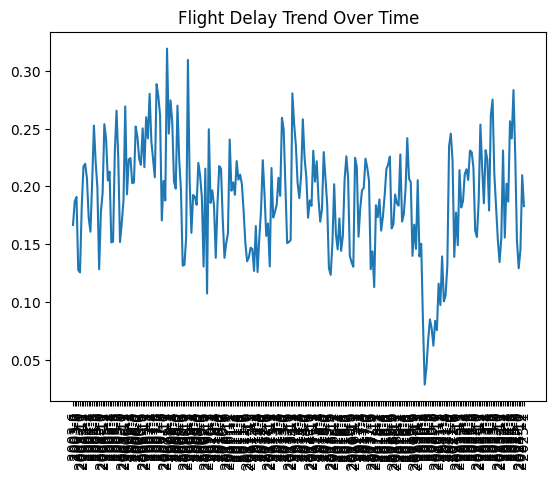

In [ ]:
import matplotlib.pyplot as plt

pandas_trend["date"] = pandas_trend["year"].astype(str) + "-" + pandas_trend["month"].astype(str)

plt.plot(pandas_trend["date"], pandas_trend["delay_rate"])
plt.xticks(rotation=90)
plt.title("Flight Delay Trend Over Time")
plt.show()

In [ ]:
airline_delay = df.groupBy("carrier_name") \
    .agg((sum("arr_del15") / sum("arr_flights")).alias("delay_rate")) \
    .orderBy(desc("delay_rate"))

pdf = airline_delay.toPandas()

In [ ]:
display(pdf.head(5))

,carrier_name,delay_rate
0,Peninsula Airways Inc.,0.314534
1,Frontier Airlines,0.262179
2,Trans States Airlines,0.246016
3,Atlantic Southeast Airlines,0.244661
4,JetBlue Airways,0.243891


<Axes: xlabel='carrier_name'>

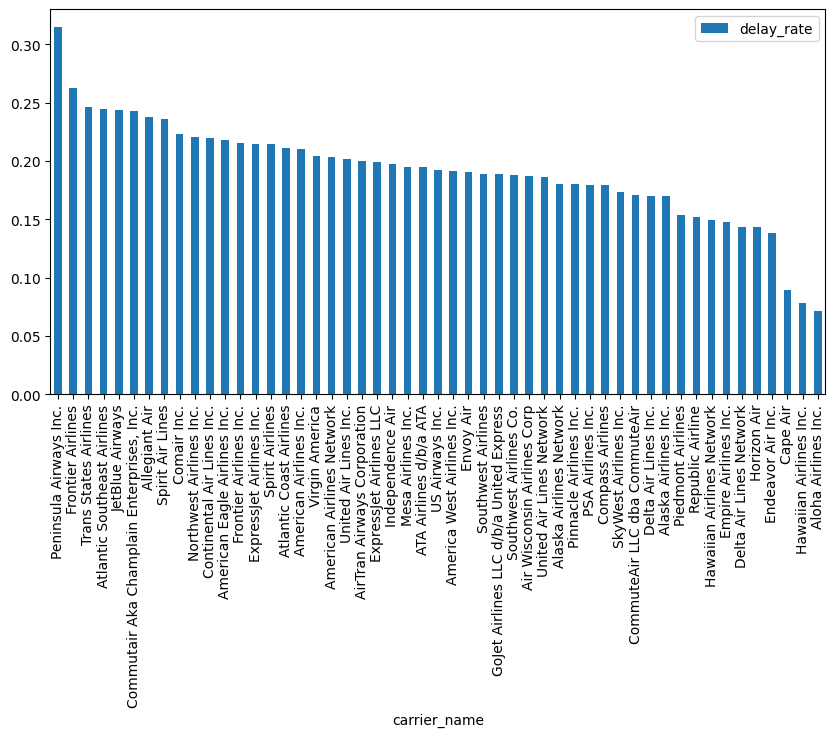

In [ ]:
pdf.plot.bar(x="carrier_name", y="delay_rate", figsize=(10,5))

<Axes: xlabel='carrier_name'>

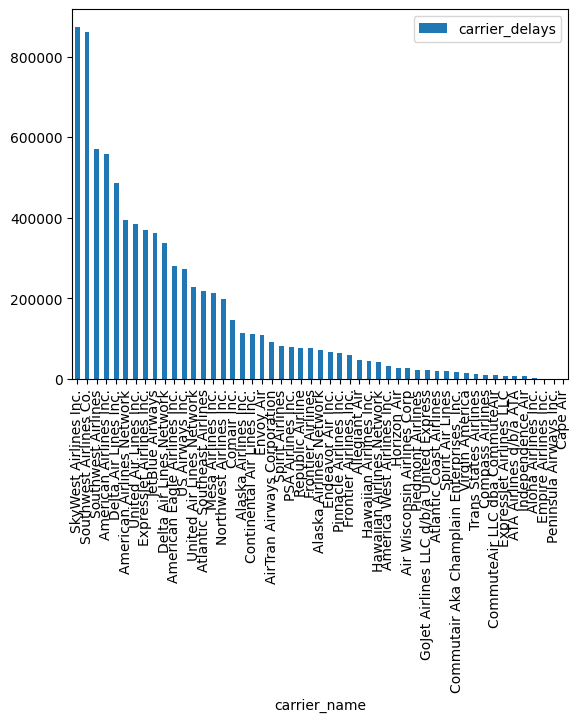

In [ ]:
carrier_delay = df.groupBy("carrier_name") \
    .agg(sum("carrier_ct").alias("carrier_delays")) \
    .orderBy(desc("carrier_delays"))

carrier_pdf = carrier_delay.toPandas()
carrier_pdf.plot.bar(x="carrier_name", y="carrier_delays")

<Axes: xlabel='airport'>

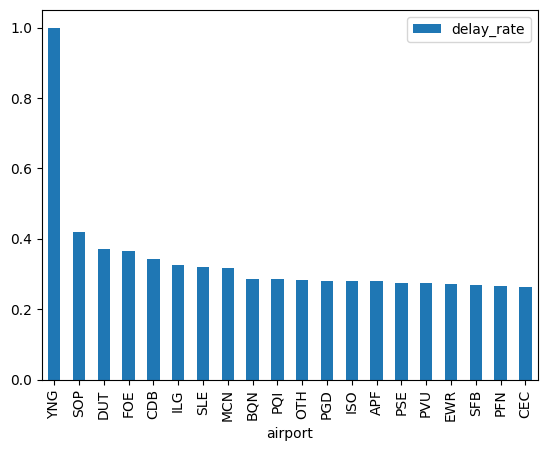

In [ ]:
airport_delay = df.groupBy("airport") \
    .agg((sum("arr_del15") / sum("arr_flights")).alias("delay_rate")) \
    .orderBy(desc("delay_rate"))

airport_pdf = airport_delay.toPandas()
airport_pdf.head(20).plot.bar(x="airport", y="delay_rate")

<Axes: >

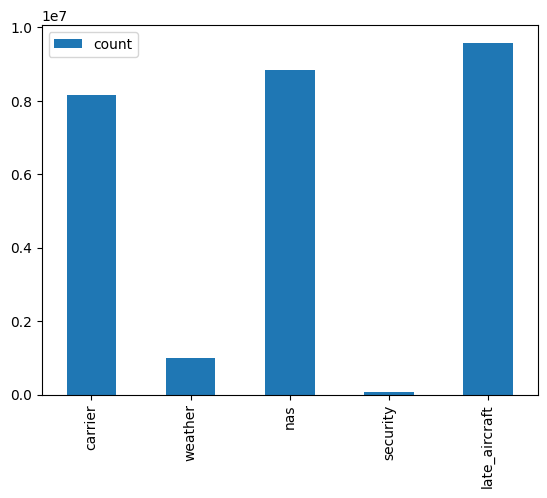

In [ ]:
causes = df.agg(
    sum("carrier_ct").alias("carrier"),
    sum("weather_ct").alias("weather"),
    sum("nas_ct").alias("nas"),
    sum("security_ct").alias("security"),
    sum("late_aircraft_ct").alias("late_aircraft")
).toPandas().T

causes.columns = ["count"]
causes.plot(kind="bar", stacked=True)

In [ ]:
monthly_causes = df.groupBy("month").agg(
    sum("carrier_ct").alias("carrier"),
    sum("weather_ct").alias("weather"),
    sum("nas_ct").alias("nas"),
    sum("security_ct").alias("security"),
    sum("late_aircraft_ct").alias("late_aircraft")
).orderBy("month")

pdf = monthly_causes.toPandas()

<Axes: xlabel='month'>

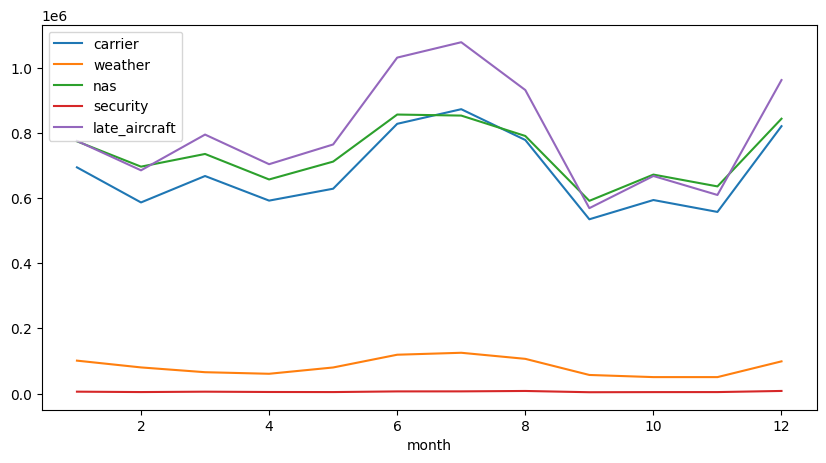

In [ ]:
monthly_causes = df.groupBy("month").agg(
    sum("carrier_ct").alias("carrier"),
    sum("weather_ct").alias("weather"),
    sum("nas_ct").alias("nas"),
    sum("security_ct").alias("security"),
    sum("late_aircraft_ct").alias("late_aircraft")
).orderBy("month")

pdf = monthly_causes.toPandas()

pdf.set_index("month").plot(kind="line", figsize=(10,5))

<Axes: xlabel='month'>

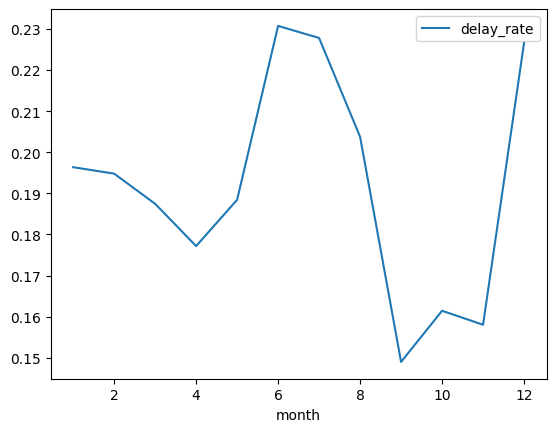

In [ ]:
month_delay = df.groupBy("month") \
    .agg((sum("arr_del15") / sum("arr_flights")).alias("delay_rate")) \
    .orderBy("month")

pdf = month_delay.toPandas()

pdf.plot(x="month", y="delay_rate", kind="line")

In [ ]:
pdf.to_csv('pdf_dataframe.csv', index=False)
print('pdf DataFrame exported to pdf_dataframe.csv')

pdf DataFrame exported to pdf_dataframe.csv
